# Message Intelligence System
Classifying messages as Spam or Not Spam using KNN, SVM and Naive Bayes.

### 1. Setting up the environment

*Intuition: We bring in the tools for handling data, drawing graphs, and building models before writing any logic.*

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import warnings
warnings.filterwarnings("ignore")

### 2. Reading in the data

*Intuition: Loading the data first lets us see what we're actually working with before deciding how to clean it.*

In [41]:
raw_data = pd.read_csv("../Dataset/Message_Intelligence_Dataset.csv")
raw_data.sample(5)

,message_id,message_text,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,timestamp,hour_of_day,day_of_week,spam_label
5094,905095,Your order has been shipped and will arrive by...,67,12,0,0,0,0,1,46.8,242.0,4.0,2025-12-06 06:00:00,6,5,0
3421,903422,Payment received successfully for your subscri...,70,9,0,4,0,0,1,37.0,157.0,8.0,2025-11-15 19:00:00,19,5,0
1823,901824,Reminder: your appointment is confirmed for Fr...,74,10,0,0,0,0,1,41.5,413.0,7.0,2025-10-27 06:00:00,6,0,0
1979,901980,Congratulations! You have won exclusive bonus ...,70,8,1,4,2,1,0,69.3,70.0,27.0,2025-11-27 21:00:00,21,3,1
2216,902217,Act fast! Your account will be suspended unles...,87,13,1,4,2,1,0,74.1,145.0,12.0,2025-12-17 21:00:00,21,2,1


### 3. Getting familiar with the data

*Intuition: Checking types and missing values early helps us catch problems before they affect the model.*

In [42]:
raw_data.info()
raw_data.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5200 entries, 0 to 5199
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   message_id               5200 non-null   int64  
 1   message_text             5200 non-null   object 
 2   message_length           5200 non-null   int64  
 3   word_count               5200 non-null   int64  
 4   num_urls                 5200 non-null   int64  
 5   num_digits               5200 non-null   int64  
 6   num_special_chars        5200 non-null   int64  
 7   spam_keyword_score       5200 non-null   int64  
 8   legit_keyword_score      5200 non-null   int64  
 9   sender_activity_score    5094 non-null   float64
 10  sender_account_age_days  5087 non-null   float64
 11  messages_sent_last_24h   5038 non-null   float64
 12  timestamp                5200 non-null   object 
 13  hour_of_day              5200 non-null   int64  
 14  day_of_week             

message_id                   0
message_text                 0
message_length               0
word_count                   0
num_urls                     0
num_digits                   0
num_special_chars            0
spam_keyword_score           0
legit_keyword_score          0
sender_activity_score      106
sender_account_age_days    113
messages_sent_last_24h     162
timestamp                    0
hour_of_day                  0
day_of_week                  0
spam_label                   0
dtype: int64

### 4. How is each feature distributed?

*Intuition: Seeing how values are spread out tells us if scaling will matter later on.*

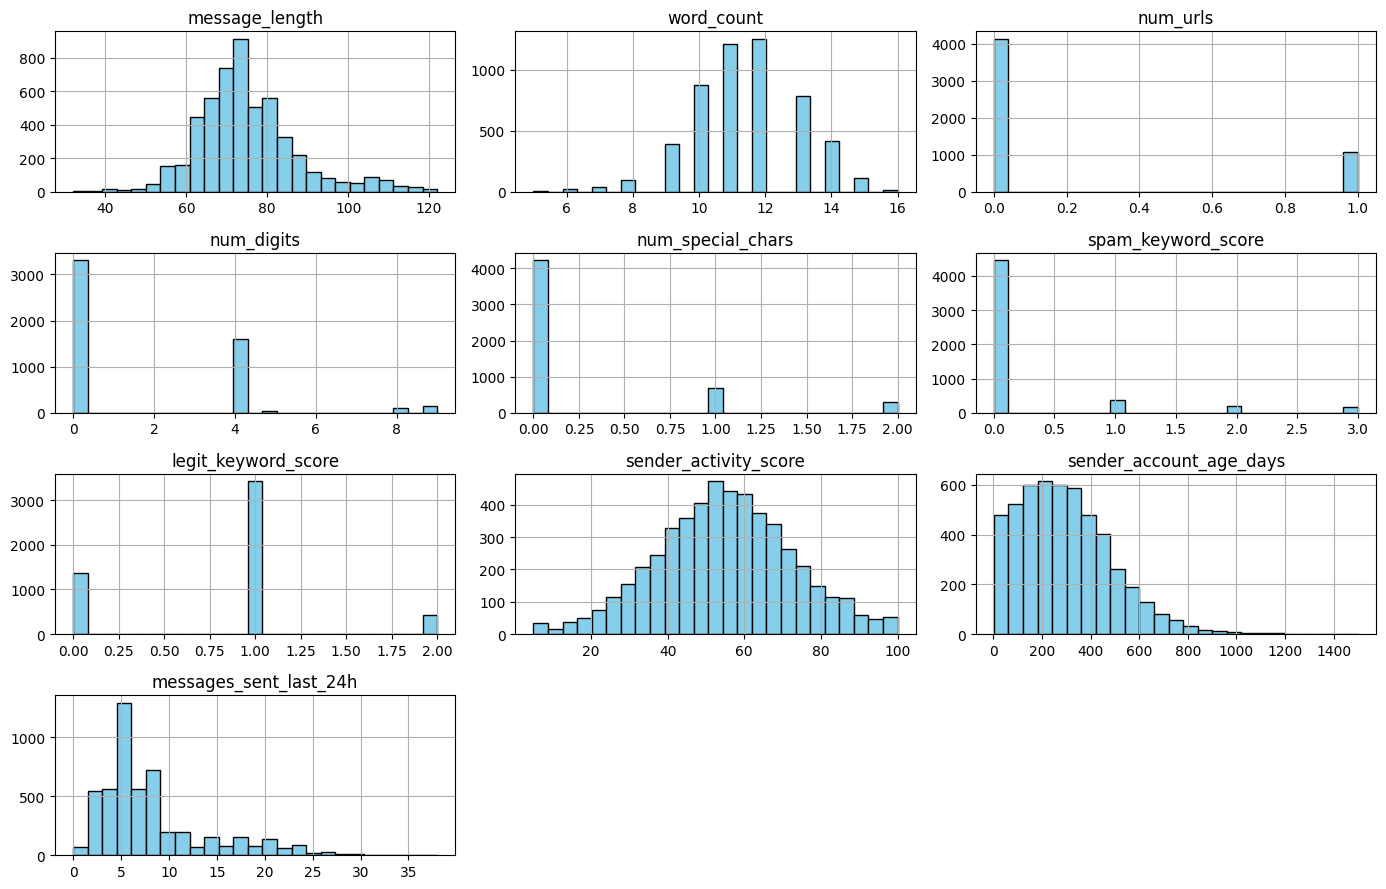

In [43]:
feature_cols = ['message_length', 'word_count', 'num_urls', 'num_digits',
                'num_special_chars', 'spam_keyword_score', 'legit_keyword_score',
                'sender_activity_score', 'sender_account_age_days', 'messages_sent_last_24h']

raw_data[feature_cols].hist(figsize=(14,9), bins=25, color='skyblue', edgecolor='black')
plt.tight_layout()
plt.show()

### 5. Which features actually relate to the label?

*Intuition: Features that correlate strongly with the label are likely to be the most useful signals for classification.*

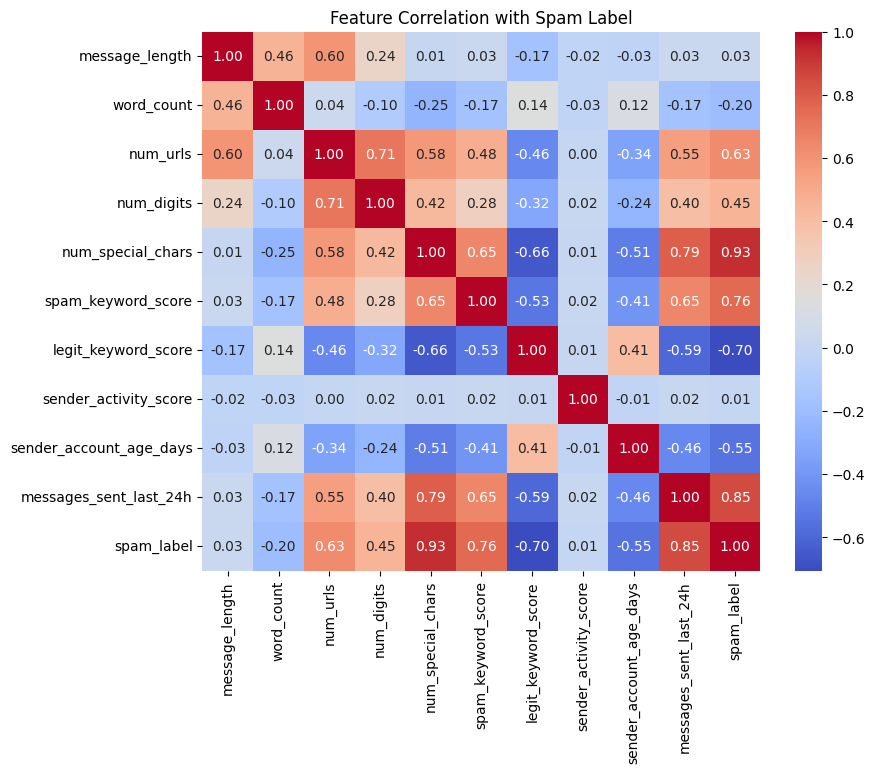

In [44]:
plt.figure(figsize=(9,7))
sns.heatmap(raw_data[feature_cols + ['spam_label']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation with Spam Label")
plt.show()

### 6. Turning the timestamp into something usable

*Intuition: A raw date can't be used by a model directly, so we pull out the parts, like month and weekend, that might actually carry a pattern.*

In [45]:
raw_data['timestamp'] = pd.to_datetime(raw_data['timestamp'])
raw_data['sent_month'] = raw_data['timestamp'].dt.month
raw_data['sent_on_weekend'] = raw_data['timestamp'].dt.dayofweek.isin([5, 6]).astype(int)
raw_data = raw_data.drop(columns=['timestamp'])

### 7. Removing columns that won't help the model

*Intuition: An ID number and raw text don't carry numeric meaning a model can use, so they're not worth keeping as-is.*

In [46]:
clean_data = raw_data.drop(columns=['message_id', 'message_text'])
clean_data.head()

,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,hour_of_day,day_of_week,spam_label,sent_month,sent_on_weekend
0,99,11,1,4,0,0,1,56.6,500.0,6.0,2,0,0,11,0
1,73,12,0,0,0,0,0,16.6,207.0,0.0,21,2,0,12,0
2,67,13,0,0,0,0,1,25.7,418.0,6.0,13,5,0,11,1
3,64,13,0,4,0,0,1,48.8,276.0,5.0,23,2,0,12,0
4,84,14,0,0,0,0,1,33.0,683.0,7.0,11,5,0,11,1


### 8. Splitting into inputs and the label we want to predict

*Intuition: A model needs to clearly know what it's looking at (features) versus what it's trying to predict (target).*

In [47]:
features = clean_data.drop(columns=['spam_label'])
target = clean_data['spam_label']

### 9. Filling in the gaps

*Intuition: Even one missing value can break a model, so we fill gaps with a value that won't distort the overall pattern.*

In [48]:
features = features.fillna(features.median())

### 10. Creating train and test sets

*Intuition: We hold back some data the model never sees during training, so we can honestly check how well it generalizes.*

In [49]:
train_X, test_X, train_y, test_y = train_test_split(
    features, target, test_size=0.2, random_state=7, stratify=target
)

### 11. Scaling - fit on train only, to keep the test set truly unseen

*Intuition: Distance and margin based models are sensitive to scale, so we bring every feature onto the same range, using only the training data to avoid leaking test information.*

In [50]:
scaler = StandardScaler()

train_X = pd.DataFrame(scaler.fit_transform(train_X), columns=features.columns)
test_X = pd.DataFrame(scaler.transform(test_X), columns=features.columns)

### 12. A quick helper so we don't repeat the same metric code for every model

*Intuition: Since every model needs the same four metrics calculated, writing it once saves us from repeating the same code three times.*

In [51]:
def get_scores(model_name, actual, predicted):
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(actual, predicted),
        'Precision': precision_score(actual, predicted),
        'Recall': recall_score(actual, predicted),
        'F1 Score': f1_score(actual, predicted)
    }

## Model 1: K-Nearest Neighbors

### 13. Building the baseline KNN model

*Intuition: The simplest way to classify a new message is to check what similar messages turned out to be.*

In [52]:
model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(train_X, train_y)
pred_knn = model_knn.predict(test_X)

print("Baseline KNN accuracy:", accuracy_score(test_y, pred_knn))

Baseline KNN accuracy: 0.9990384615384615


### 14. Tuning K

*Intuition: Too few neighbors can overreact to noise, and too many can blur the boundary, so we test a range to find a sweet spot.*

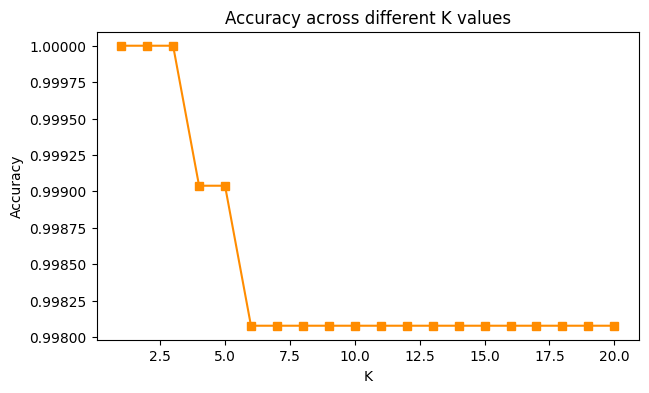

Optimal K: 1


In [53]:
k_range = range(1, 21)
acc_per_k = []

for k in k_range:
    temp_model = KNeighborsClassifier(n_neighbors=k)
    temp_model.fit(train_X, train_y)
    temp_pred = temp_model.predict(test_X)
    acc_per_k.append(accuracy_score(test_y, temp_pred))

plt.figure(figsize=(7,4))
plt.plot(k_range, acc_per_k, marker='s', color='darkorange')
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("Accuracy across different K values")
plt.show()

optimal_k = k_range[np.argmax(acc_per_k)]
print("Optimal K:", optimal_k)

### 15. Does the distance metric matter?

*Intuition: How we define 'closeness' can shift which neighbors count as nearest, so it's worth checking if it changes results.*

In [54]:
for metric in ['euclidean', 'manhattan', 'minkowski']:
    temp_model = KNeighborsClassifier(n_neighbors=optimal_k, metric=metric)
    temp_model.fit(train_X, train_y)
    temp_pred = temp_model.predict(test_X)
    print(f"{metric}: {accuracy_score(test_y, temp_pred)}")

euclidean: 1.0
manhattan: 1.0
minkowski: 1.0


### 16. Where does KNN go wrong?

*Intuition: Looking at where the model is wrong tells us more about its limits than just looking at the accuracy number.*

In [55]:
model_knn = KNeighborsClassifier(n_neighbors=optimal_k)
model_knn.fit(train_X, train_y)
pred_knn = model_knn.predict(test_X)

wrong_preds = test_X[pred_knn != test_y.values].index
clean_data.loc[wrong_preds].head()

,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,hour_of_day,day_of_week,spam_label,sent_month,sent_on_weekend


## Model 2: Support Vector Machine

### 17. Building Linear and RBF SVM models

*Intuition: Instead of comparing to neighbors, SVM tries to draw the cleanest possible boundary that keeps both classes as far apart as possible.*

In [56]:
model_svm_linear = SVC(kernel='linear')
model_svm_linear.fit(train_X, train_y)
pred_svm_linear = model_svm_linear.predict(test_X)

model_svm_rbf = SVC(kernel='rbf')
model_svm_rbf.fit(train_X, train_y)
pred_svm_rbf = model_svm_rbf.predict(test_X)

print("Linear kernel accuracy:", accuracy_score(test_y, pred_svm_linear))
print("RBF kernel accuracy:", accuracy_score(test_y, pred_svm_rbf))

Linear kernel accuracy: 1.0
RBF kernel accuracy: 1.0


### 18. A look at the support vectors

*Intuition: Only the points closest to the boundary actually matter to SVM - these are the support vectors.*

In [57]:
print("Support vectors (Linear):", model_svm_linear.n_support_)
print("Support vectors (RBF):", model_svm_rbf.n_support_)

Support vectors (Linear): [8 4]
Support vectors (RBF): [90 74]


### 19. SVM vs KNN, side by side

*Intuition: Comparing them side by side shows whether a margin-based approach beats a distance-based one on this data.*

In [58]:
pd.DataFrame([
    get_scores("KNN", test_y, pred_knn),
    get_scores("SVM (Linear)", test_y, pred_svm_linear),
    get_scores("SVM (RBF)", test_y, pred_svm_rbf)
])

,Model,Accuracy,Precision,Recall,F1 Score
0,KNN,1.0,1.0,1.0,1.0
1,SVM (Linear),1.0,1.0,1.0,1.0
2,SVM (RBF),1.0,1.0,1.0,1.0


## Model 3: Naive Bayes

### 20. Building the Naive Bayes model

*Intuition: Naive Bayes flips the logic - instead of geometry, it asks purely how probable each class is given what we've observed.*

In [59]:
model_nb = GaussianNB()
model_nb.fit(train_X, train_y)
pred_nb = model_nb.predict(test_X)

print("Naive Bayes accuracy:", accuracy_score(test_y, pred_nb))

Naive Bayes accuracy: 1.0


### 21. Working out a probability by hand

*Intuition: Working this out by hand with one feature makes it obvious what the model is actually calculating internally.*

In [60]:
pick_index = test_X.index[0]
digit_count = round(clean_data.loc[pick_index, 'num_digits'])

spam_rows = clean_data[clean_data['spam_label'] == 1]
legit_rows = clean_data[clean_data['spam_label'] == 0]

chance_given_spam = (spam_rows['num_digits'].round() == digit_count).sum() / len(spam_rows)
chance_given_legit = (legit_rows['num_digits'].round() == digit_count).sum() / len(legit_rows)

print("P(num_digits =", digit_count, "| Spam):", chance_given_spam)
print("P(num_digits =", digit_count, "| Not Spam):", chance_given_legit)

P(num_digits = 4 | Spam): 0.5817060637204522
P(num_digits = 4 | Not Spam): 0.24532765554766975


### 22. Bringing in Bayes' Theorem

*Intuition: Bayes' Theorem is just combining how common a class is overall with how likely the evidence is for that class.*

In [61]:
prior_spam = (train_y == 1).mean()
prior_legit = (train_y == 0).mean()

weighted_spam = chance_given_spam * prior_spam
weighted_legit = chance_given_legit * prior_legit
total_weight = weighted_spam + weighted_legit

final_spam_prob = weighted_spam / total_weight
final_legit_prob = weighted_legit / total_weight

print("P(Spam | num_digits):", final_spam_prob)
print("P(Not Spam | num_digits):", final_legit_prob)

P(Spam | num_digits): 0.3529435485106995
P(Not Spam | num_digits): 0.6470564514893006


### 23. Hand-calculated vs model-calculated

*Intuition: If our hand calculation roughly matches the model's own output, it confirms we understood the math correctly.*

In [62]:
model_probs = model_nb.predict_proba(test_X.loc[[pick_index]])

print("By hand   -> Not Spam:", final_legit_prob, "| Spam:", final_spam_prob)
print("By model  -> Not Spam:", model_probs[0][0], "| Spam:", model_probs[0][1])

By hand   -> Not Spam: 0.6470564514893006 | Spam: 0.3529435485106995
By model  -> Not Spam: 1.0 | Spam: 0.0


## Bringing It All Together

### 24. Comparing all three models

*Intuition: Putting every model's metrics in one table makes it easy to judge trade-offs at a glance.*

In [63]:
score_table = pd.DataFrame([
    get_scores('KNN', test_y, pred_knn),
    get_scores('SVM (Linear)', test_y, pred_svm_linear),
    get_scores('SVM (RBF)', test_y, pred_svm_rbf),
    get_scores('Naive Bayes', test_y, pred_nb)
])
score_table

,Model,Accuracy,Precision,Recall,F1 Score
0,KNN,1.0,1.0,1.0,1.0
1,SVM (Linear),1.0,1.0,1.0,1.0
2,SVM (RBF),1.0,1.0,1.0,1.0
3,Naive Bayes,1.0,1.0,1.0,1.0


### 25. Visual comparison

*Intuition: A chart makes the differences between models easier to spot than scanning numbers in a table.*

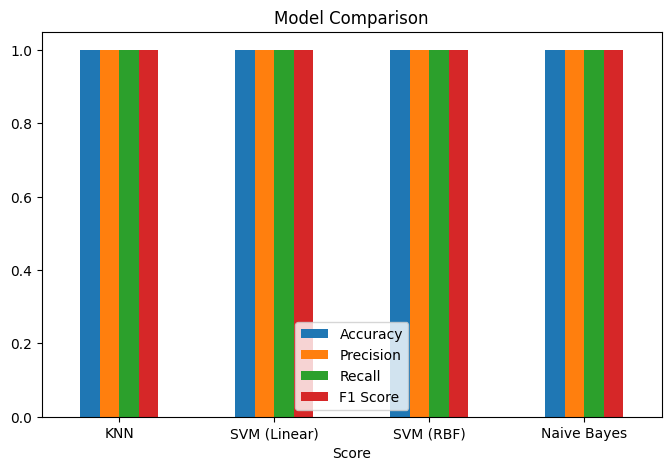

In [64]:
score_table.set_index('Model').plot(kind='bar', figsize=(8,5))
plt.xlabel("Score")
plt.xticks(rotation=0)
plt.title("Model Comparison")
plt.show()

### 26. Picking a winner for precision and recall

*Intuition: Depending on the use case, we might care more about avoiding false alarms (precision) or catching every spam message (recall).*

In [65]:
print("Highest Precision:", score_table.loc[score_table['Precision'].idxmax(), 'Model'])
print("Highest Recall:", score_table.loc[score_table['Recall'].idxmax(), 'Model'])

Highest Precision: KNN
Highest Recall: KNN


### 27. Wrapping up

- **KNN** is easy to understand but can slow down as the dataset grows.
- **SVM** draws a strong boundary between classes but is harder to interpret.
- **Naive Bayes** is fast and probability-driven, though it assumes features don't influence each other.

The model with the strongest overall F1 Score is the most balanced choice for real-world deployment, since it manages both false alarms and missed spam messages effectively.